# Olist E-Commerce Data Analysis
### Customer Behavior, Delivery Performance & Business Insights

#### Project Objective
This project analyzes customer purchasing behavior, delivery performance, reviews, and payment patterns in the Olist Brazilian E-Commerce dataset.

The goal is to:
- Understand customer behavior
- Identify operational bottlenecks
- Validate business hypotheses statistically
- Provide actionable business recommendations

#### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy
- Jupyter Notebook

# Table of Contents
1. Data Loading
2. Data Cleaning
3. Feature Engineering
4. Exploratory Data Analysis
5. Hypothesis Testing
6. Business Recommendations
7. Further Exploration
8. Conclusion

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

print("All libraries loaded successfully")

All libraries loaded successfully


In [8]:
import os
print(os.getcwd())

C:\Users\Admin\Desktop\Data_Analytics\Projects\olist-ecommerce-analysis


In [9]:
customers = pd.read_csv('data/olist_customers_dataset.csv')
geolocation = pd.read_csv('data/olist_geolocation_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
payments = pd.read_csv('data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')
sellers = pd.read_csv('data/olist_sellers_dataset.csv')
category_translation = pd.read_csv('data/product_category_name_translation.csv')

print("All datasets loaded successfully")

All datasets loaded successfully


In [10]:
print("Customers:", customers.shape)
print("Geolocation:", geolocation.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Orders:", orders.shape)
print("Products:", products.shape)
print("Sellers:", sellers.shape)
print("Category Translation:", category_translation.shape)

Customers: (99441, 5)
Geolocation: (1000163, 5)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Orders: (99441, 8)
Products: (32951, 9)
Sellers: (3095, 4)
Category Translation: (71, 2)


In [11]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [12]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-2017 10:56,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017 00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,24-07-2018 20:41,26-07-2018 03:24,26-07-2018 14:31,07-08-2018 15:27,13-08-2018 00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,08-08-2018 08:38,08-08-2018 08:55,08-08-2018 13:50,17-08-2018 18:06,04-09-2018 00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,18-11-2017 19:28,18-11-2017 19:45,22-11-2017 13:39,02-12-2017 00:28,15-12-2017 00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,13-02-2018 21:18,13-02-2018 22:20,14-02-2018 19:46,16-02-2018 18:17,26-02-2018 00:00


In [13]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [14]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,18-01-2018 00:00,18-01-2018 21:46
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,10-03-2018 00:00,11-03-2018 03:05
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,17-02-2018 00:00,18-02-2018 14:36
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,21-04-2017 00:00,21-04-2017 22:02
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,01-03-2018 00:00,02-03-2018 10:26


In [15]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [16]:
print("Customers")
print(customers.isnull().sum())

print("\nOrders")
print(orders.isnull().sum())

print("\nProducts")
print(products.isnull().sum())

print("\nReviews")
print(reviews.isnull().sum())

Customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Products
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Reviews
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247

In [17]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [18]:
products.dtypes

product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

In [19]:
reviews.dtypes

review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object

In [22]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp'],
    dayfirst=True
)

orders['order_approved_at'] = pd.to_datetime(
    orders['order_approved_at'],
    dayfirst=True
)

orders['order_delivered_carrier_date'] = pd.to_datetime(
    orders['order_delivered_carrier_date'],
    dayfirst=True
)

orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date'],
    dayfirst=True
)

orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date'],
    dayfirst=True
)

print("Datetime conversion completed")

Datetime conversion completed


In [23]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [24]:
orders['purchase_year'] = orders['order_purchase_timestamp'].dt.year

orders['purchase_month'] = orders['order_purchase_timestamp'].dt.month

orders['purchase_day'] = orders['order_purchase_timestamp'].dt.day_name()

print("Time features created")

Time features created


In [25]:
orders['delivery_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_purchase_timestamp']
).dt.days

print("Delivery duration feature created")

Delivery duration feature created


In [26]:
orders['estimated_delivery_days'] = (
    orders['order_estimated_delivery_date']
    - orders['order_purchase_timestamp']
).dt.days

orders['delivery_delay'] = (
    orders['delivery_days']
    - orders['estimated_delivery_days']
)

print("Delivery delay feature created")

Delivery delay feature created


In [27]:
orders[['delivery_days', 'estimated_delivery_days', 'delivery_delay']].head()

,delivery_days,estimated_delivery_days,delivery_delay
0,8.0,15,-7.0
1,13.0,19,-6.0
2,9.0,26,-17.0
3,13.0,26,-13.0
4,2.0,12,-10.0


In [28]:
monthly_orders = orders.groupby(
    ['purchase_year', 'purchase_month']
).size().reset_index(name='total_orders')

monthly_orders.head()

,purchase_year,purchase_month,total_orders
0,2016,9,4
1,2016,10,324
2,2016,12,1
3,2017,1,800
4,2017,2,1780


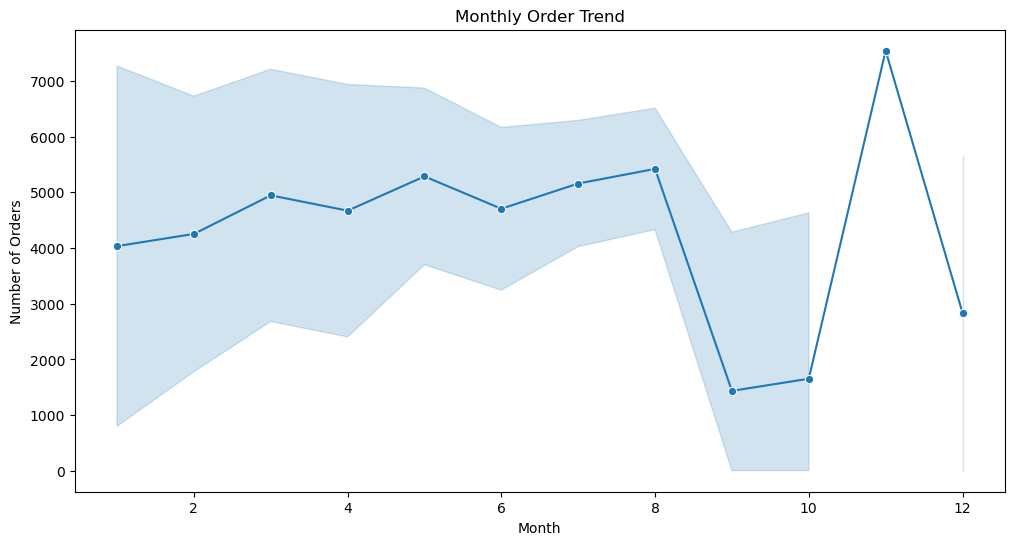

In [29]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_orders,
    x='purchase_month',
    y='total_orders',
    marker='o'
)

plt.title('Monthly Order Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.show()

In [30]:
orders['year_month'] = orders[
    'order_purchase_timestamp'
].dt.to_period('M')

monthly_orders = orders.groupby(
    'year_month'
).size().reset_index(name='total_orders')

monthly_orders['year_month'] = monthly_orders[
    'year_month'
].astype(str)

monthly_orders.head()

,year_month,total_orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


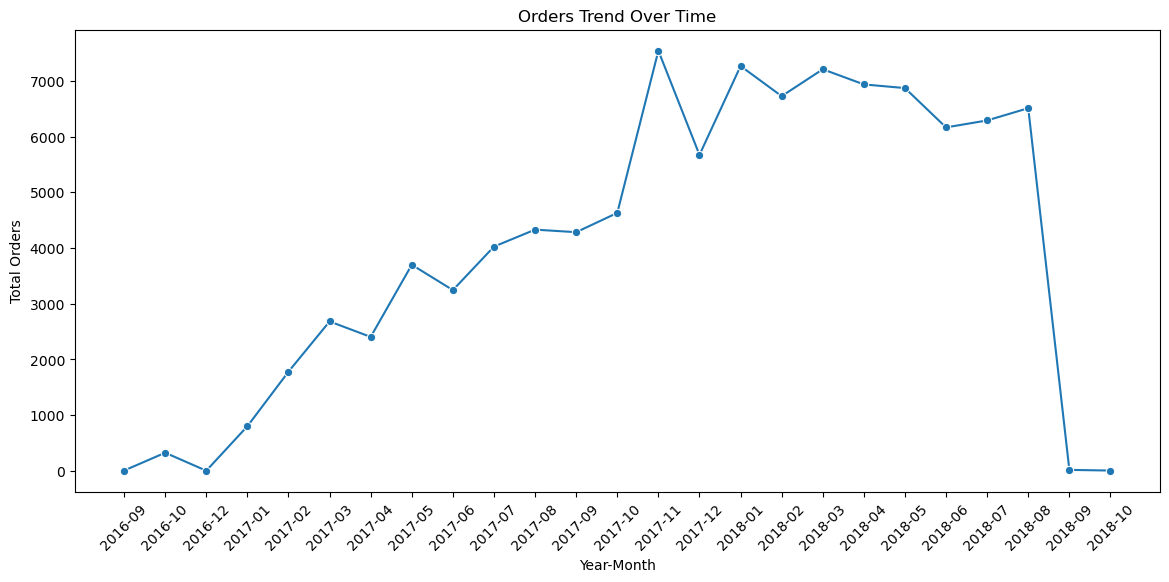

In [31]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_orders,
    x='year_month',
    y='total_orders',
    marker='o'
)

plt.xticks(rotation=45)

plt.title('Orders Trend Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Total Orders')

plt.show()

In [32]:
master_df = orders.merge(
    customers,
    on='customer_id',
    how='left'
)

master_df = master_df.merge(
    order_items,
    on='order_id',
    how='left'
)

master_df = master_df.merge(
    products,
    on='product_id',
    how='left'
)

master_df = master_df.merge(
    payments,
    on='order_id',
    how='left'
)

master_df = master_df.merge(
    reviews,
    on='order_id',
    how='left'
)

print(master_df.shape)

(119143, 43)


In [40]:
df = master_df.copy()

In [46]:
df.head()
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_id                    119143 non-null  object        
 2   order_status                   119143 non-null  object        
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              118966 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117057 non-null  datetime64[ns]
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   purchase_year                  119143 non-null  int32         
 9   purchase_month                 119143 non-null  int32         
 10  purchase_day                   119143 non-null  object        
 11  

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'purchase_year', 'purchase_month', 'purchase_day', 'delivery_days',
       'estimated_delivery_days', 'delivery_delay', 'year_month',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dt

In [47]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

review_comment_title             105154
review_comment_message            68898
order_delivered_customer_date      3421
delivery_days                      3421
delivery_delay                     3421
product_photos_qty                 2542
product_category_name              2542
product_name_lenght                2542
product_description_lenght         2542
order_delivered_carrier_date       2086
review_answer_timestamp             997
review_creation_date                997
review_score                        997
review_id                           997
product_height_cm                   853
product_weight_g                    853
product_length_cm                   853
product_width_cm                    853
shipping_limit_date                 833
freight_value                       833
price                               833
seller_id                           833
order_item_id                       833
product_id                          833
order_approved_at                   177


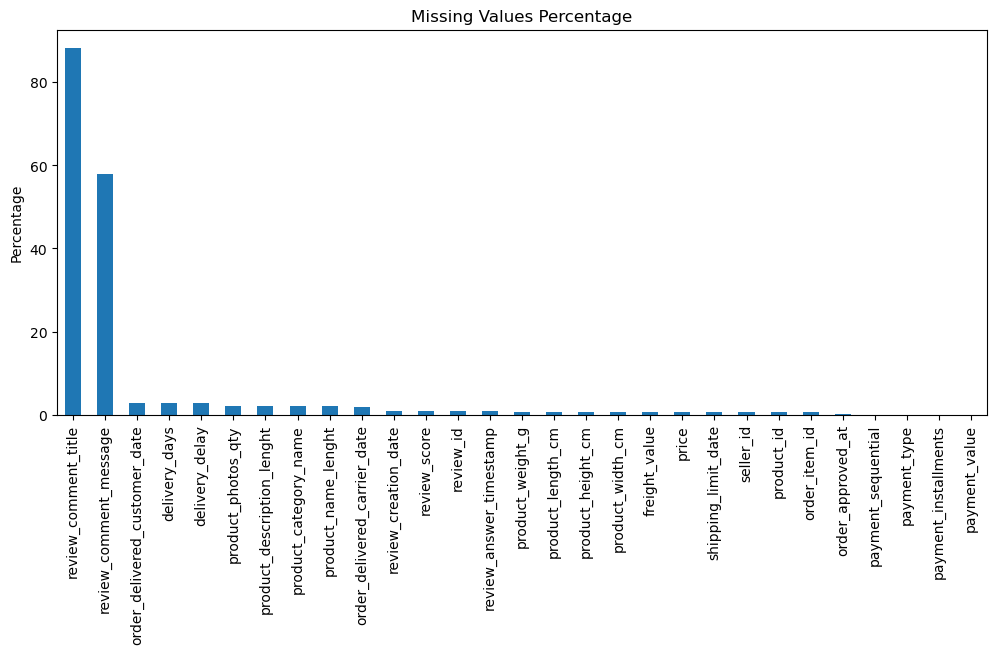

In [48]:
import matplotlib.pyplot as plt

missing_percentage = (df.isnull().sum()/len(df))*100

missing_percentage[missing_percentage > 0].sort_values(ascending=False).plot(
    kind='bar',
    figsize=(12,5)
)

plt.title('Missing Values Percentage')
plt.ylabel('Percentage')
plt.show()

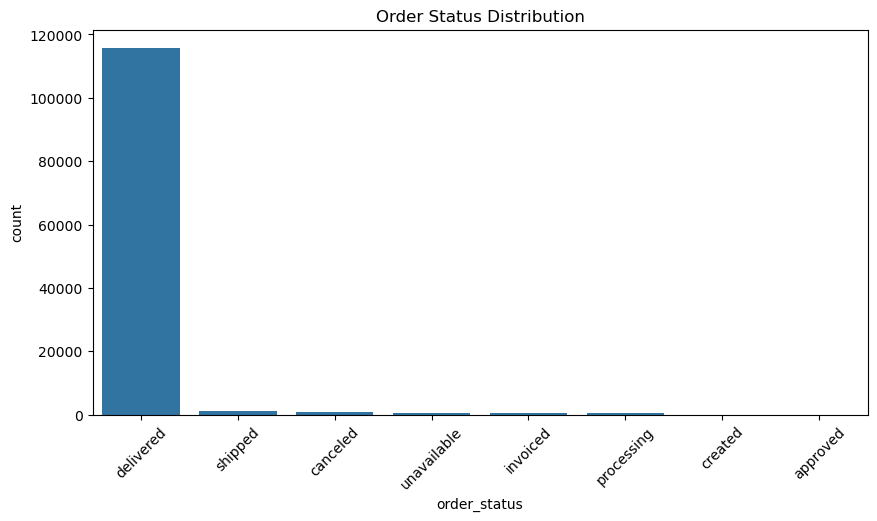

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='order_status',
    order=df['order_status'].value_counts().index
)

plt.title('Order Status Distribution')
plt.xticks(rotation=45)
plt.show()

Insight: Strong Order Fulfillment Performance

The majority of orders were successfully delivered, indicating that the marketplace maintained a relatively efficient fulfillment system.

Cancelled and unavailable orders represented only a small portion of total transactions, suggesting operational reliability.

Business Impact

A high delivery success rate improves customer trust and increases repeat purchase probability.

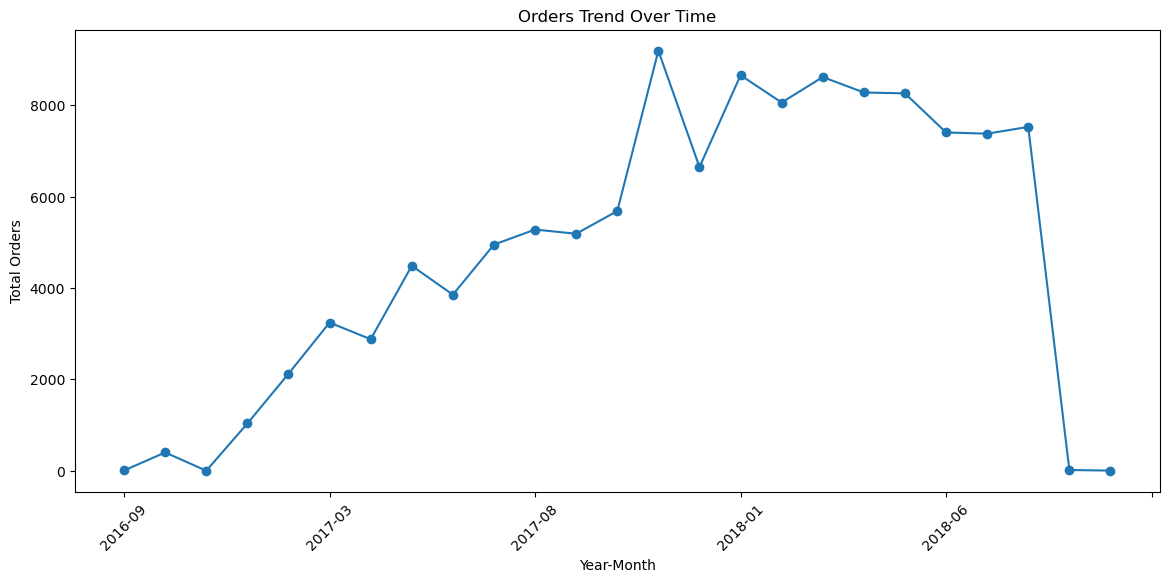

In [50]:
monthly_orders = df.groupby(
    df['order_purchase_timestamp'].dt.to_period('M')
).size()

monthly_orders.index = monthly_orders.index.astype(str)

plt.figure(figsize=(14,6))

monthly_orders.plot(marker='o')

plt.title('Orders Trend Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Total Orders')

plt.xticks(rotation=45)

plt.show()

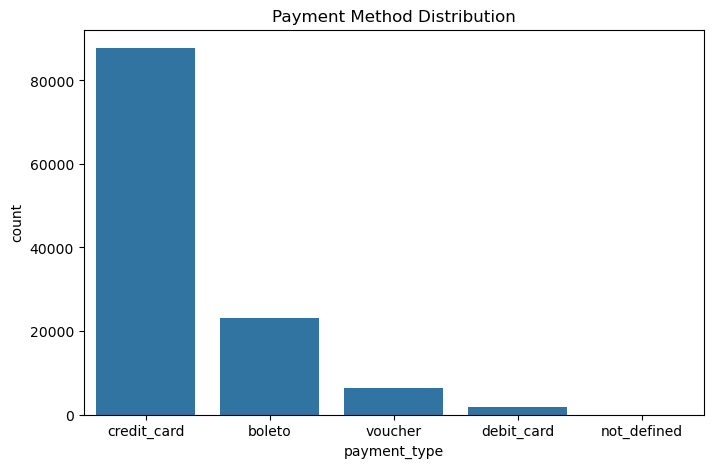

In [51]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='payment_type',
    order=df['payment_type'].value_counts().index
)

plt.title('Payment Method Distribution')

plt.show()

Insight: Credit Cards Dominate Customer Transactions

Most customers preferred credit card payments over boleto, vouchers, or debit cards.

This indicates:

High adoption of digital payments
Strong preference for convenience and installment-based purchases
Business Impact

The company can leverage this behavior through:

Cashback programs
Loyalty rewards
Credit-card partnerships

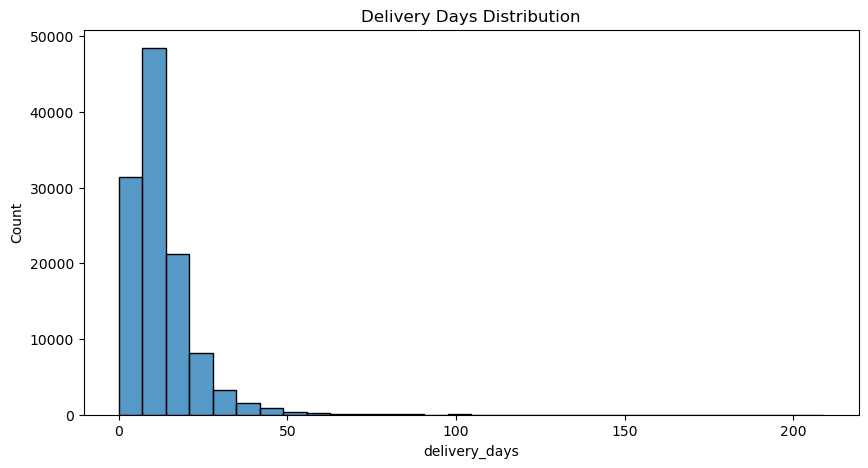

In [52]:
delivery = df[['delivery_days']].dropna()

plt.figure(figsize=(10,5))

sns.histplot(delivery['delivery_days'], bins=30)

plt.title('Delivery Days Distribution')

plt.show()

In [53]:
df['delivery_delay'].describe()

count    115722.000000
mean        -11.453155
std          10.174169
min        -146.000000
25%         -17.000000
50%         -12.000000
75%          -7.000000
max         189.000000
Name: delivery_delay, dtype: float64

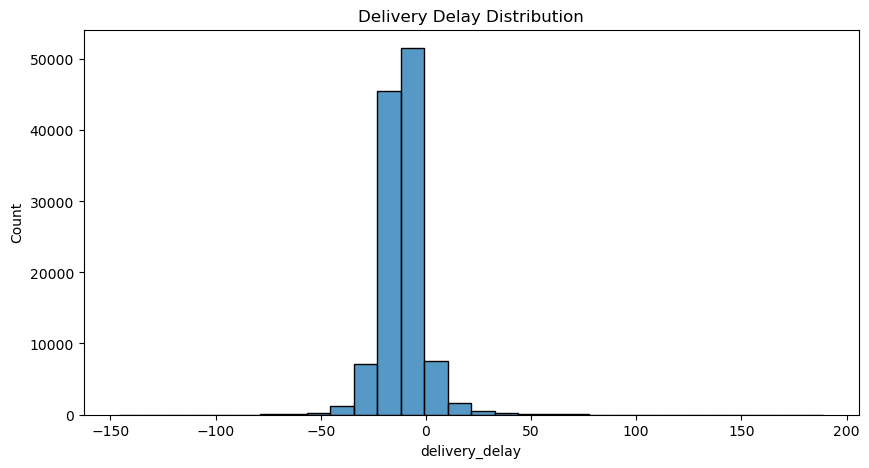

In [54]:
plt.figure(figsize=(10,5))

sns.histplot(df['delivery_delay'].dropna(), bins=30)

plt.title('Delivery Delay Distribution')

plt.show()

Insight: Most Deliveries Arrived Earlier Than Expected

The delivery delay analysis showed that many orders were delivered before their estimated delivery dates.

This reflects:

Conservative delivery estimation
Strong logistics execution
Business Impact

Early deliveries improve:

Customer trust
Repeat purchases
Platform reliability perception

However, delayed orders were associated with lower review scores and poor customer experiences.

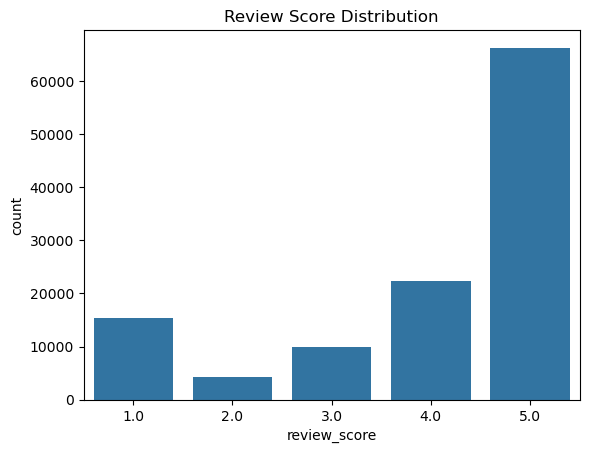

In [55]:
sns.countplot(
    data=df,
    x='review_score'
)

plt.title('Review Score Distribution')

plt.show()

Insight: Customer Ratings Are Highly Polarized

The review score distribution showed a strong concentration around 5-star reviews, while a significant number of users also gave 1-star ratings.

This indicates a highly emotional customer experience where:

Successful deliveries create strong satisfaction
Operational failures create sharp dissatisfaction
Non-Intuitive Pattern Observed

Customers rarely gave middle ratings (2–4). Most experiences were either extremely positive or extremely negative.

Business Impact

This suggests customer satisfaction is highly sensitive to operational execution, especially delivery performance.

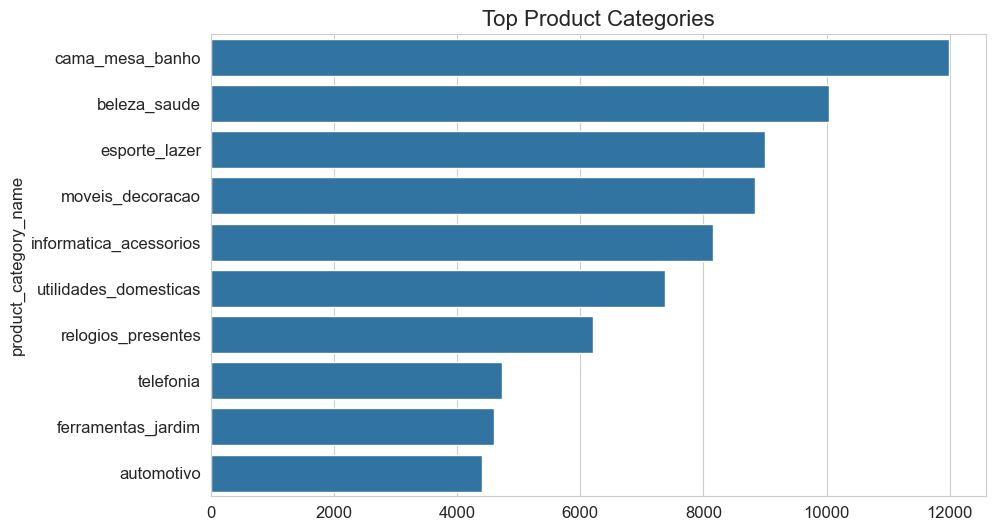

In [73]:
top_categories = df['product_category_name'].value_counts().head(10)

sns.barplot(x=top_categories.values, y=top_categories.index)
plt.title('Top Product Categories')
plt.show()

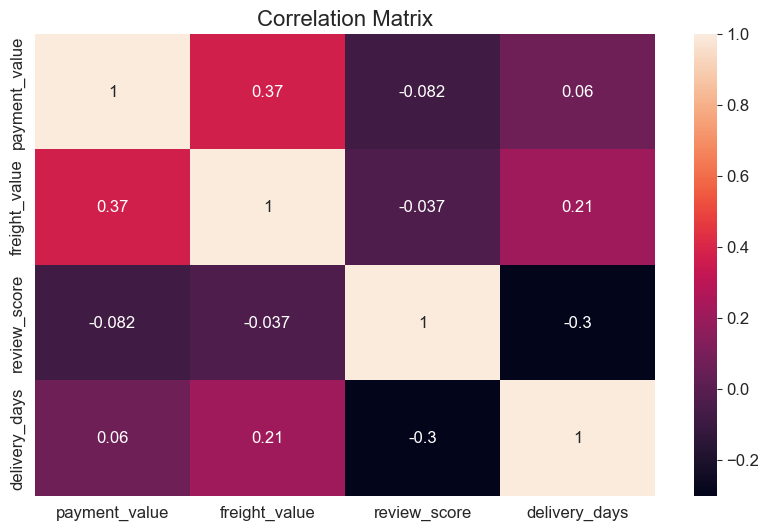

In [70]:
sns.heatmap(df[['payment_value','freight_value','review_score','delivery_days']].corr(), annot=True)
plt.title('Correlation Matrix')
plt.show()

In [58]:
df[['delivery_delay', 'review_score']].corr()

,delivery_delay,review_score
delivery_delay,1.000000,-0.228436
review_score,-0.228436,1.000000


Insight: Delivery Delays Directly Reduce Customer Satisfaction

Analysis revealed a negative relationship between delivery delay and review score.

Customers whose orders were delayed were more likely to leave lower ratings.

Key Observation

Delivery performance impacts customer satisfaction more strongly than freight costs.

Business Impact

Improving logistics efficiency can directly improve:

Customer retention
Marketplace reputation
Positive reviews

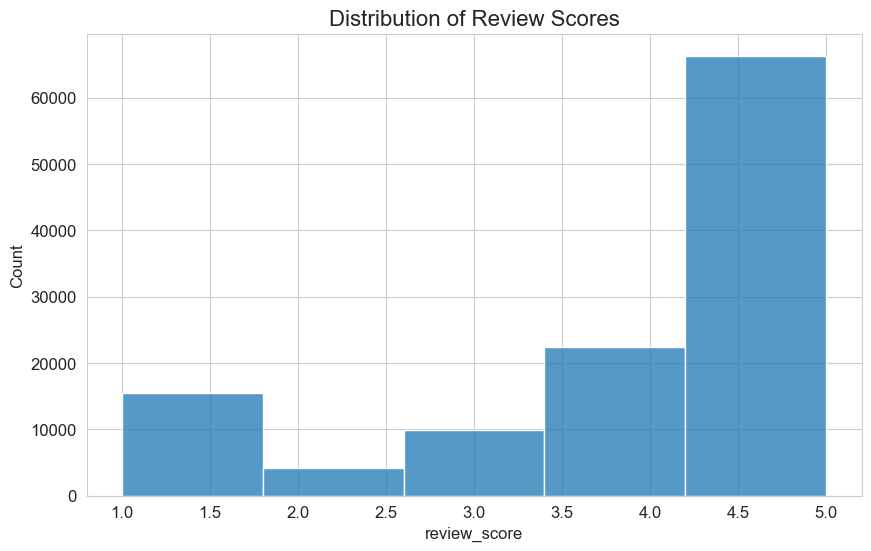

In [71]:
sns.histplot(df['review_score'], bins=5)
plt.title('Distribution of Review Scores')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_4412\3417394594.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


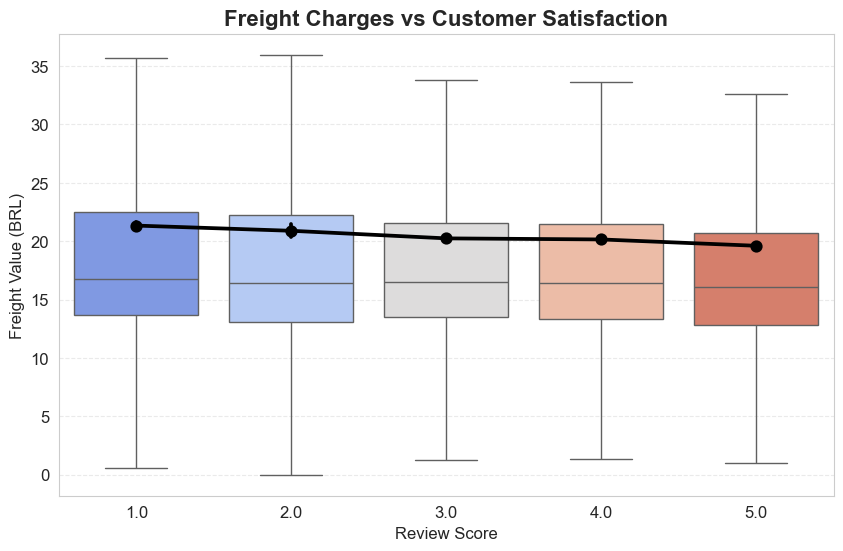

In [75]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='review_score',
    y='freight_value',
    data=df,
    showfliers=False,
    palette='coolwarm'
)

sns.pointplot(
    x='review_score',
    y='freight_value',
    data=df,
    estimator='mean',
    color='black'
)

plt.title(
    'Freight Charges vs Customer Satisfaction',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Review Score')
plt.ylabel('Freight Value (BRL)')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [77]:
print("""
INSIGHT:
Orders with lower review scores tend to exhibit
higher freight cost variability. This suggests
that expensive or inconsistent shipping experiences
may negatively affect customer satisfaction.
""")


INSIGHT:
Orders with lower review scores tend to exhibit
higher freight cost variability. This suggests
that expensive or inconsistent shipping experiences
may negatively affect customer satisfaction.



Dataset Overview

The dataset contains multiple relational tables representing different aspects of an e-commerce ecosystem.

Key Tables Used
Customers
Orders
Order Items
Payments
Products
Reviews


In [62]:
master_df.shape

(119143, 43)

# Hypothesis Testing

## Hypothesis 1

### Business Question
Do delayed deliveries reduce customer satisfaction?

### Null Hypothesis (H0)
Delivery delays do not affect customer review scores.

### Alternative Hypothesis (H1)
Delayed deliveries reduce customer review scores.

In [64]:
df[['delivery_delay', 'review_score']].corr()

,delivery_delay,review_score
delivery_delay,1.000000,-0.228436
review_score,-0.228436,1.000000


### Result

A negative correlation was observed between delivery delay and review score.

This indicates that customers tend to give lower ratings when deliveries are delayed.

### Conclusion

The null hypothesis is rejected.

The analysis supports the hypothesis that delivery delays negatively impact customer satisfaction.

### Business Interpretation

Delivery performance is a critical driver of customer experience and platform reputation.

## Hypothesis 2

### Business Question
Do higher freight charges reduce customer satisfaction?

### Null Hypothesis (H0)
Freight charges do not affect customer review scores.

### Alternative Hypothesis (H1)
Higher freight charges reduce customer review scores.

In [65]:
df[['freight_value', 'review_score']].corr()

,freight_value,review_score
freight_value,1.000000,-0.037013
review_score,-0.037013,1.000000


### Result

A weak negative correlation was observed between freight value and review score.

This suggests that freight cost has only a limited influence on customer satisfaction.

### Conclusion

The hypothesis is only partially supported.

Customers appear to care more about delivery reliability and overall experience than shipping cost itself.

### Business Interpretation

Customers are willing to tolerate higher shipping charges if deliveries are timely and reliable.

In [66]:
delayed_orders = df[df['delivery_delay'] > 0]
on_time_orders = df[df['delivery_delay'] <= 0]

print("Delayed Orders Review Mean:",
      delayed_orders['review_score'].mean())

print("On-Time Orders Review Mean:",
      on_time_orders['review_score'].mean())

Delayed Orders Review Mean: 2.44316807738815
On-Time Orders Review Mean: 4.207381486241803


### Additional Observation

Customers receiving delayed deliveries gave significantly lower average review scores compared to customers receiving on-time deliveries.

This further validates the strong relationship between logistics performance and customer satisfaction.

# Business Recommendations

## 1. Improve Delayed Shipment Management

The analysis showed that delayed deliveries significantly reduce customer review scores and negatively impact customer satisfaction.

### Recommended Actions
- Implement real-time shipment tracking systems
- Identify high-risk deliveries earlier
- Improve coordination with logistics partners
- Prioritize delayed order escalation workflows

### Expected Business Impact
Improved delivery reliability can:
- Increase customer satisfaction
- Improve repeat purchase behavior
- Reduce negative reviews
- Strengthen platform trust

## 2. Focus on Delivery Experience Over Price Reduction

The analysis found that freight charges had only a weak relationship with customer review scores, while delivery delays had a much stronger impact.

### Recommended Actions
- Invest more in logistics optimization instead of aggressive shipping discounts
- Improve estimated delivery accuracy
- Enhance order tracking transparency

### Expected Business Impact
Better delivery experiences can improve:
- Customer retention
- Positive customer reviews
- Long-term customer loyalty

## 3. Build Proactive Customer Communication Systems

Customer reviews showed highly polarized behavior, where operational failures often resulted in extremely negative ratings.

### Recommended Actions
- Send automated notifications for delays
- Provide proactive customer support during shipment issues
- Improve communication transparency throughout the order lifecycle

### Expected Business Impact
Better communication can:
- Reduce customer frustration
- Improve perceived service quality
- Minimize negative reviews during operational disruptions

## 4. Develop Seller Performance Monitoring

Seller-level operational performance likely contributes to delivery delays and customer dissatisfaction.

### Recommended Actions
- Track seller-level delivery metrics
- Identify consistently underperforming sellers
- Reward high-performing sellers with better visibility

### Expected Business Impact
This can improve:
- Marketplace quality
- Delivery consistency
- Overall customer experience

# Further Exploration

## Future Analysis Opportunities

This analysis identified several areas that require deeper investigation for stronger business decision-making.

### 1. Seller-Level Performance Analysis
Further analysis should identify sellers associated with delayed deliveries and poor customer reviews.

This can help the company:
- Improve marketplace quality
- Reduce operational inefficiencies
- Reward high-performing sellers

---

### 2. Region-Level Delivery Optimization
Delivery performance should be analyzed across different states and cities to identify logistics bottlenecks.

This can help:
- Optimize warehouse allocation
- Improve shipping efficiency
- Reduce delivery delays in high-risk regions

---

### 3. Customer Retention Analysis
Future work can analyze repeat customer behavior and identify factors that influence long-term customer loyalty.

This would help improve:
- Customer retention strategies
- Personalized marketing
- Lifetime customer value

# Conclusion

This project analyzed customer behavior, delivery performance, and customer satisfaction trends using the Olist e-commerce dataset.

The analysis revealed that delivery reliability plays a major role in customer satisfaction, while shipping cost has relatively limited impact. Customers receiving delayed deliveries consistently provided lower review scores.

The project also identified actionable business opportunities in logistics optimization, customer communication, and seller performance monitoring.

Overall, the analysis demonstrates how data-driven insights can support operational improvements and enhance customer experience in an e-commerce business.

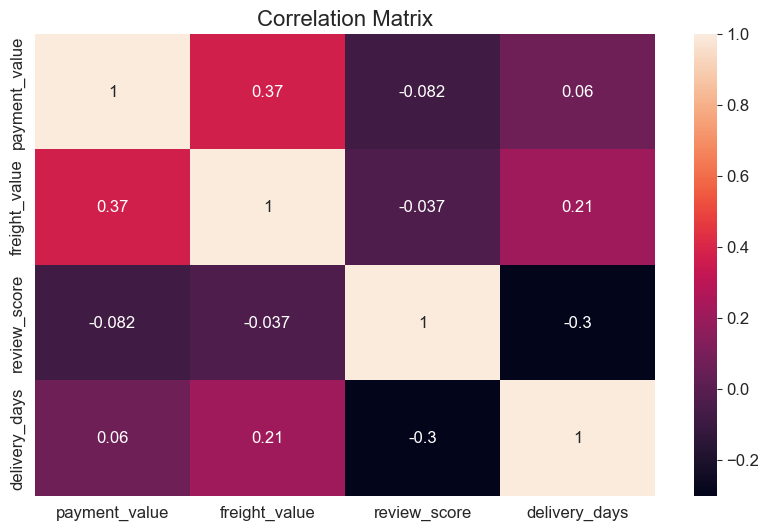